In [ ]:
!pip uninstall -y numpy autofeat

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder
from statsmodels.imputation import mice


# 学習用データの読み込み
train_data = pd.read_csv("../data/train_preprocessed.csv")
test_data = pd.read_csv("../data/test_preprocessed.csv")


train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean()).round(0)
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].mean()).round(0)

train_data['MonthlyIncome'] = train_data['MonthlyIncome'].fillna(train_data['MonthlyIncome'].mean()).round(0)
test_data['MonthlyIncome'] = test_data['MonthlyIncome'].fillna(test_data['MonthlyIncome'].mean()).round(0)

train_data['DurationOfPitch'] = train_data['DurationOfPitch'].fillna(train_data['DurationOfPitch'].mean()).round(0)
test_data['DurationOfPitch'] = test_data['DurationOfPitch'].fillna(test_data['DurationOfPitch'].mean()).round(0)

imp = mice.MICEData(train_data)
imp.update_all(n_iter=20)
train_data = imp.data

imp = mice.MICEData(test_data)
imp.update_all(n_iter=20)
test_data = imp.data


train_data['CityTier'] = train_data['CityTier'].replace({1: 2, 2: 1, 3: 0})
test_data['CityTier'] = test_data['CityTier'].replace({1: 2, 2: 1, 3: 0})


train_data['Occupation'] = train_data['Occupation'].replace({0: 'Large_Business', 1: 'Salaried', 2: 'Small_Business'})
enc = OneHotEncoder(sparse_output=False)
encoded_occupation = enc.fit_transform(train_data[['Occupation']])
encoded_df = pd.DataFrame(encoded_occupation, columns=enc.get_feature_names_out(['Occupation']))
insert_position = 'CityTier'  # この列の後に挿入
cols = train_data.columns.tolist()
insert_idx = cols.index(insert_position) + 1
front_part = train_data.iloc[:, :insert_idx]  # CityTierまで
back_part = train_data.iloc[:, insert_idx:].drop('Occupation', axis=1)  # Occupation以降（Occupation除く）
train_data = pd.concat([front_part, encoded_df, back_part], axis=1)
train_data[encoded_df.columns] = train_data[encoded_df.columns].astype(int)

test_data['Occupation'] = test_data['Occupation'].replace({0: 'Large_Business', 1: 'Salaried', 2: 'Small_Business'})
enc = OneHotEncoder(sparse_output=False)
encoded_occupation = enc.fit_transform(test_data[['Occupation']])
encoded_df = pd.DataFrame(encoded_occupation, columns=enc.get_feature_names_out(['Occupation']))
insert_position = 'CityTier'  # この列の後に挿入
cols = test_data.columns.tolist()
insert_idx = cols.index(insert_position) + 1
front_part = test_data.iloc[:, :insert_idx]  # CityTierまで
back_part = test_data.iloc[:, insert_idx:].drop('Occupation', axis=1)  # Occupation以降（Occupation除く）
test_data = pd.concat([front_part, encoded_df, back_part], axis=1)
test_data[encoded_df.columns] = test_data[encoded_df.columns].astype(int)


train_data['NumberOfPersonVisiting'] = train_data['NumberOfPersonVisiting'].astype(int)
test_data['NumberOfPersonVisiting'] = test_data['NumberOfPersonVisiting'].astype(int)

train_data['NumberOfFollowups'] = train_data['NumberOfFollowups'].where(~(train_data['NumberOfFollowups'] == 100), train_data['NumberOfFollowups']/100)
train_data['NumberOfFollowups'] = train_data['NumberOfFollowups'].where(~(train_data['NumberOfFollowups'] == 200), train_data['NumberOfFollowups']/100)
train_data['NumberOfFollowups'] = train_data['NumberOfFollowups'].where(~(train_data['NumberOfFollowups'] == 300), train_data['NumberOfFollowups']/100)
train_data['NumberOfFollowups'] = train_data['NumberOfFollowups'].where(~(train_data['NumberOfFollowups'] == 400), train_data['NumberOfFollowups']/100)
train_data['NumberOfFollowups'] = train_data['NumberOfFollowups'].where(~(train_data['NumberOfFollowups'] == 500), train_data['NumberOfFollowups']/100)
train_data['NumberOfFollowups'] = train_data['NumberOfFollowups'].where(~(train_data['NumberOfFollowups'] == 600), train_data['NumberOfFollowups']/100)
train_data['NumberOfFollowups_6'] = np.where((train_data['NumberOfFollowups'] == 6), 1, 0)

test_data['NumberOfFollowups'] = test_data['NumberOfFollowups'].where(~(test_data['NumberOfFollowups'] == 100), test_data['NumberOfFollowups']/100)
test_data['NumberOfFollowups'] = test_data['NumberOfFollowups'].where(~(test_data['NumberOfFollowups'] == 200), test_data['NumberOfFollowups']/100)
test_data['NumberOfFollowups'] = test_data['NumberOfFollowups'].where(~(test_data['NumberOfFollowups'] == 300), test_data['NumberOfFollowups']/100)
test_data['NumberOfFollowups'] = test_data['NumberOfFollowups'].where(~(test_data['NumberOfFollowups'] == 400), test_data['NumberOfFollowups']/100)
test_data['NumberOfFollowups'] = test_data['NumberOfFollowups'].where(~(test_data['NumberOfFollowups'] == 500), test_data['NumberOfFollowups']/100)
test_data['NumberOfFollowups'] = test_data['NumberOfFollowups'].where(~(test_data['NumberOfFollowups'] == 600), test_data['NumberOfFollowups']/100)
test_data['NumberOfFollowups_6'] = np.where((test_data['NumberOfFollowups'] == 6), 1, 0)


train_data['ProductPitched'] = train_data['ProductPitched'].replace({0: 'Basic', 1: 'Standard', 2: 'Deluxe', 3: 'Super_Deluxe', 4: 'King'})
enc = OneHotEncoder(sparse_output=False)
encoded_occupation = enc.fit_transform(train_data[['ProductPitched']])
encoded_df = pd.DataFrame(encoded_occupation, columns=enc.get_feature_names_out(['ProductPitched']))
insert_position = 'NumberOfFollowups'  # この列の後に挿入
cols = train_data.columns.tolist()
insert_idx = cols.index(insert_position) + 1
front_part = train_data.iloc[:, :insert_idx]  # CityTierまで
back_part = train_data.iloc[:, insert_idx:].drop('ProductPitched', axis=1)  # Occupation以降（Occupation除く）
train_data = pd.concat([front_part, encoded_df, back_part], axis=1)
train_data[encoded_df.columns] = train_data[encoded_df.columns].astype(int)

test_data['ProductPitched'] = test_data['ProductPitched'].replace({0: 'Basic', 1: 'Standard', 2: 'Deluxe', 3: 'Super_Deluxe', 4: 'King'})
enc = OneHotEncoder(sparse_output=False)
encoded_occupation = enc.fit_transform(test_data[['ProductPitched']])
encoded_df = pd.DataFrame(encoded_occupation, columns=enc.get_feature_names_out(['ProductPitched']))
insert_position = 'NumberOfFollowups'  # この列の後に挿入
cols = test_data.columns.tolist()
insert_idx = cols.index(insert_position) + 1
front_part = test_data.iloc[:, :insert_idx]  # CityTierまで
back_part = test_data.iloc[:, insert_idx:].drop('ProductPitched', axis=1)  # Occupation以降（Occupation除く）
test_data = pd.concat([front_part, encoded_df, back_part], axis=1)
test_data[encoded_df.columns] = test_data[encoded_df.columns].astype(int)


train_data['PreferredPropertyStar'] = train_data['PreferredPropertyStar'].replace({5: 2, 4: 1, 3: 0})
test_data['PreferredPropertyStar'] = test_data['PreferredPropertyStar'].replace({5: 2, 4: 1, 3: 0})


train_data['Own_Car'] = train_data['Own_Car'].replace({0: '未所持', 1: '所持'})
enc = OneHotEncoder(sparse_output=False)
encoded_occupation = enc.fit_transform(train_data[['Own_Car']])
encoded_df = pd.DataFrame(encoded_occupation, columns=enc.get_feature_names_out(['Own_Car']))
train_data = train_data.drop('Own_Car', axis=1)
train_data = pd.concat([train_data, encoded_df], axis=1)
train_data[encoded_df.columns] = train_data[encoded_df.columns].astype(int)

test_data['Own_Car'] = test_data['Own_Car'].replace({0: '未所持', 1: '所持'})
enc = OneHotEncoder(sparse_output=False)
encoded_occupation = enc.fit_transform(test_data[['Own_Car']])
encoded_df = pd.DataFrame(encoded_occupation, columns=enc.get_feature_names_out(['Own_Car']))
test_data = test_data.drop('Own_Car', axis=1)
test_data = pd.concat([test_data, encoded_df], axis=1)
test_data[encoded_df.columns] = test_data[encoded_df.columns].astype(int)





train_data['Agebin_15_27'] = np.where((train_data['Age'] >= 15) & (train_data['Age'] <= 27), 1, 0)
train_data['Agebin_28_30'] = np.where((train_data['Age'] >= 28) & (train_data['Age'] <= 30), 1, 0)
train_data['Agebin_31_33'] = np.where((train_data['Age'] >= 31) & (train_data['Age'] <= 33), 1, 0)
train_data['Agebin_34_40'] = np.where((train_data['Age'] >= 34) & (train_data['Age'] <= 40), 1, 0)
train_data['Agebin_41_45'] = np.where((train_data['Age'] >= 41) & (train_data['Age'] <= 45), 1, 0)

test_data['Agebin_15_27'] = np.where((test_data['Age'] >= 15) & (test_data['Age'] <= 27), 1, 0)
test_data['Agebin_28_30'] = np.where((test_data['Age'] >= 28) & (test_data['Age'] <= 30), 1, 0)
test_data['Agebin_31_33'] = np.where((test_data['Age'] >= 31) & (test_data['Age'] <= 33), 1, 0)
test_data['Agebin_34_40'] = np.where((test_data['Age'] >= 34) & (test_data['Age'] <= 40), 1, 0)
test_data['Agebin_41_45'] = np.where((test_data['Age'] >= 41) & (test_data['Age'] <= 45), 1, 0)


train_data['Marriage_1'] = np.where((train_data['Marriage'] == 1), 1, 0)
test_data['Marriage_1'] = np.where((test_data['Marriage'] == 1), 1, 0)

train_data['Children_1'] = np.where((train_data['Children'] == 1), 1, 0)
test_data['Children_1'] = np.where((test_data['Children'] == 1), 1, 0)


print(train_data.head(10))

train_data.to_csv('../data/train_特徴量選択.csv')
test_data.to_csv('../data/test_特徴量選択.csv')

   id   Age  TypeofContact  CityTier  Occupation_Large_Business  \
0   0  50.0              1         1                          1   
1   1  56.0              0         2                          0   
2   2  39.0              1         2                          1   
3   3  37.0              1         1                          0   
4   4  48.0              0         0                          0   
5   5  19.0              1         1                          0   
6   6  47.0              0         0                          0   
7   7  49.0              1         1                          0   
8   8  33.0              0         1                          1   
9   9  31.0              0         2                          1   

   Occupation_Salaried  Occupation_Small_Business  DurationOfPitch  Gender  \
0                    0                          0             15.0       1   
1                    1                          0             14.0       1   
2                    0      

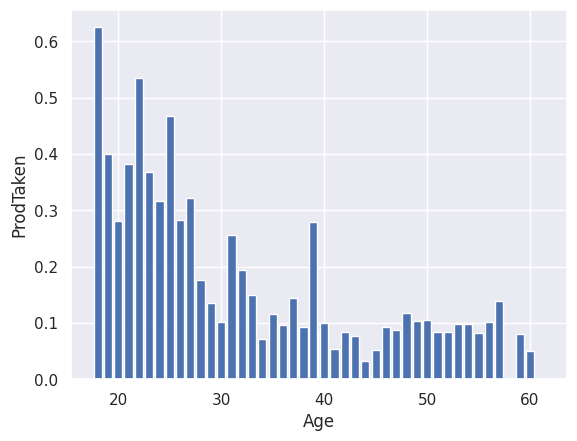

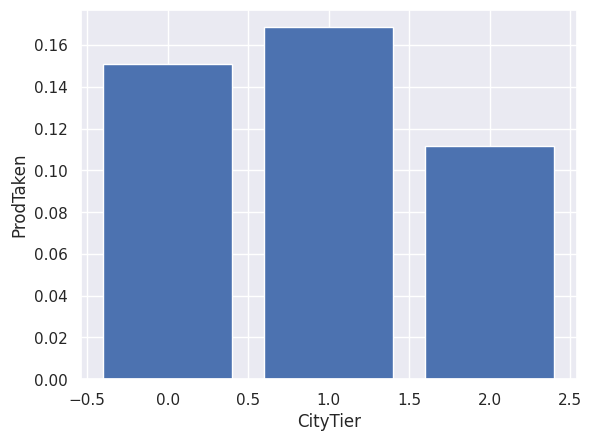

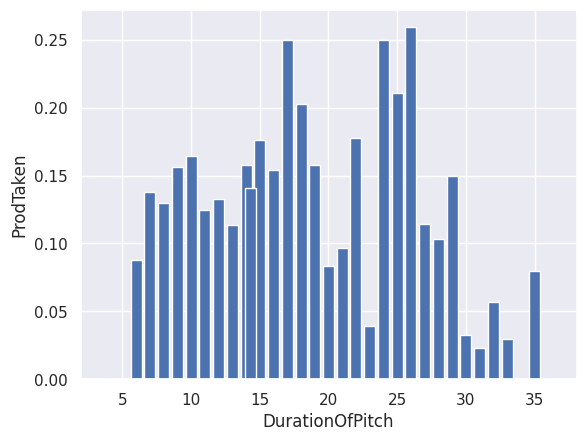

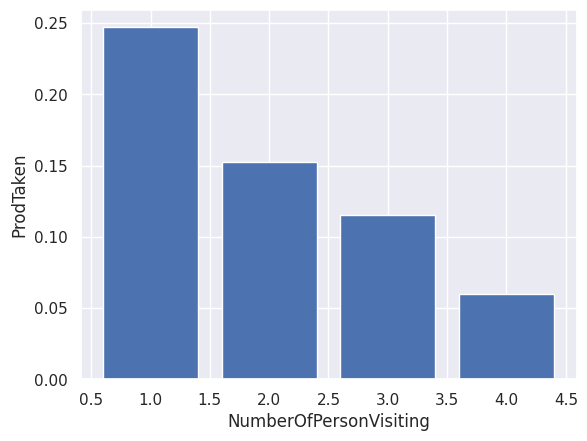

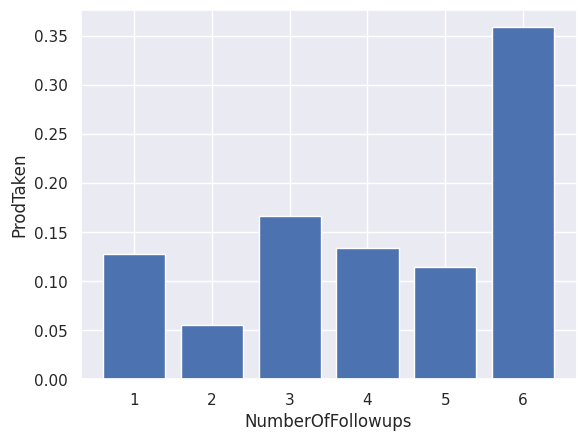

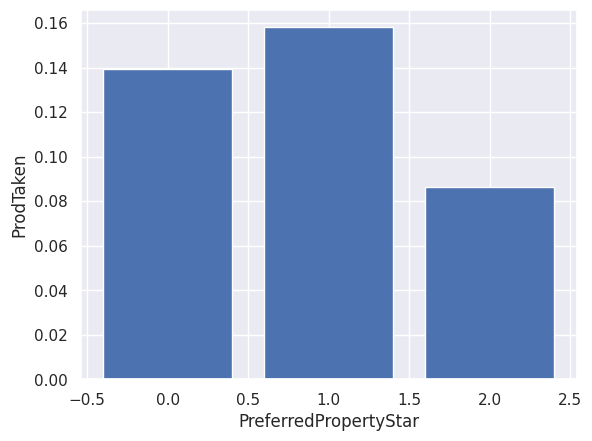

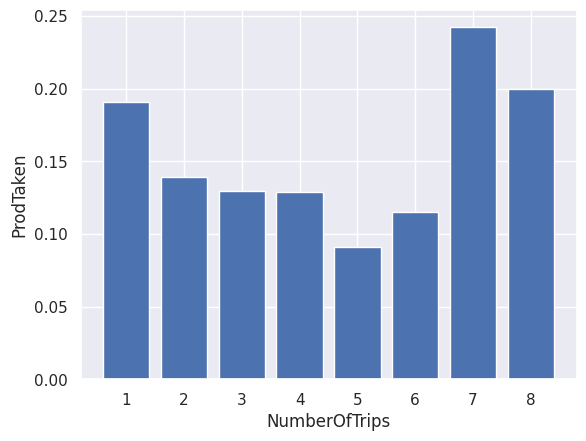

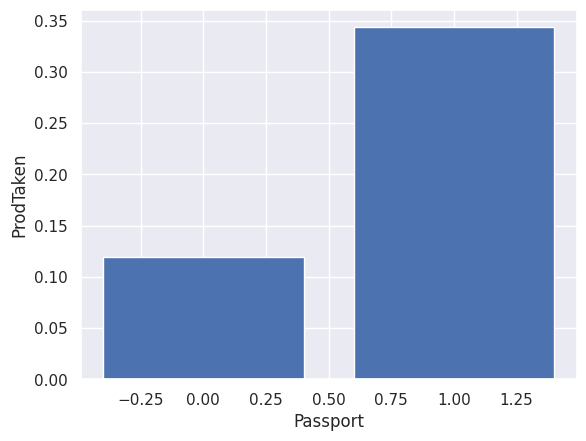

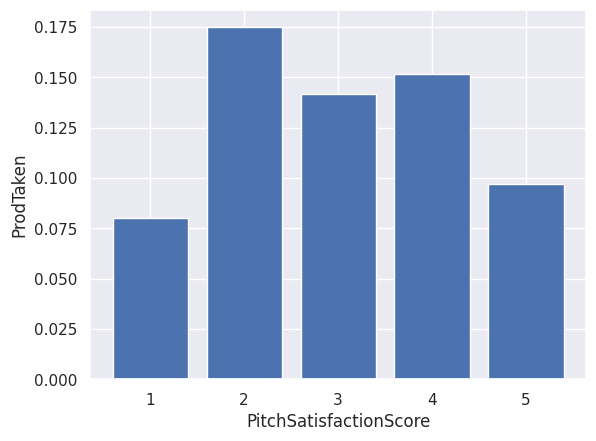

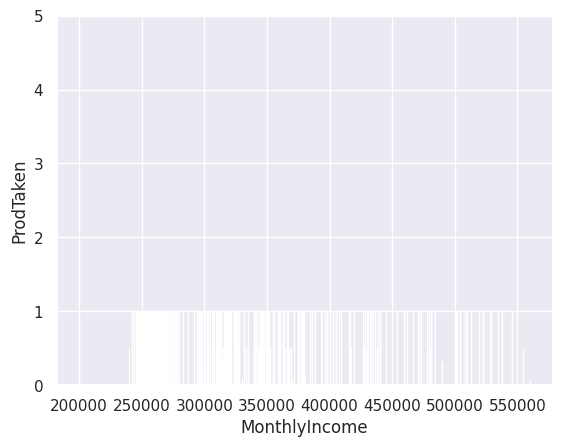

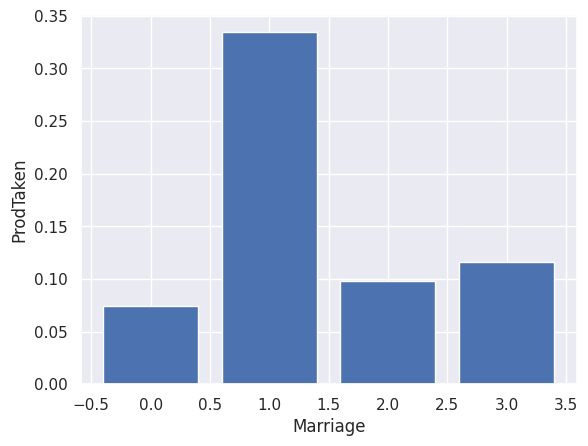

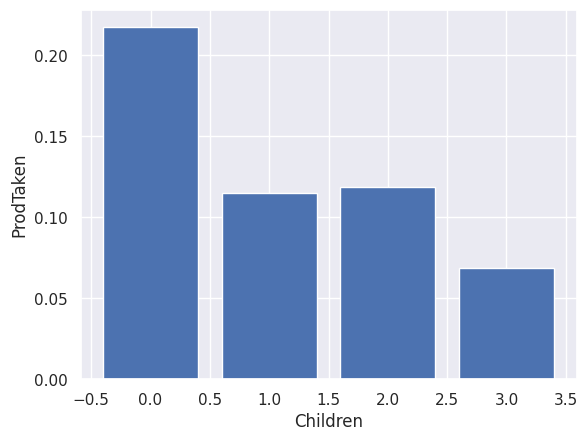

In [ ]:
grouped = train_data.groupby("Age")["ProdTaken"].agg(["mean", "count"]).sort_values(by="count", ascending=False)
plt.bar(grouped.index, grouped["mean"])
plt.ylabel('ProdTaken')
plt.xlabel('Age')
plt.savefig('../outputs/age_prod_taken.png')
plt.show()

grouped = train_data.groupby("CityTier")["ProdTaken"].agg(["mean", "count"]).sort_values(by="count", ascending=False)
plt.bar(grouped.index, grouped["mean"])
plt.ylabel('ProdTaken')
plt.xlabel('CityTier')
plt.show()

grouped = train_data.groupby("DurationOfPitch")["ProdTaken"].agg(["mean", "count"]).sort_values(by="count", ascending=False)
plt.bar(grouped.index, grouped["mean"])
plt.ylabel('ProdTaken')
plt.xlabel('DurationOfPitch')
plt.savefig('../outputs/durationofpitch_prod_taken.png')
plt.show()

grouped = train_data.groupby("NumberOfPersonVisiting")["ProdTaken"].agg(["mean", "count"]).sort_values(by="count", ascending=False)
plt.bar(grouped.index, grouped["mean"])
plt.ylabel('ProdTaken')
plt.xlabel('NumberOfPersonVisiting')
plt.show()

grouped = train_data.groupby("NumberOfFollowups")["ProdTaken"].agg(["mean", "count"]).sort_values(by="count", ascending=False)
plt.bar(grouped.index, grouped["mean"])
plt.ylabel('ProdTaken')
plt.xlabel('NumberOfFollowups')
plt.savefig('../outputs/num_followups_prod_taken.png')
plt.show()

grouped = train_data.groupby("PreferredPropertyStar")["ProdTaken"].agg(["mean", "count"]).sort_values(by="count", ascending=False)
plt.bar(grouped.index, grouped["mean"])
plt.ylabel('ProdTaken')
plt.xlabel('PreferredPropertyStar')
plt.show()

grouped = train_data.groupby("NumberOfTrips")["ProdTaken"].agg(["mean", "count"]).sort_values(by="count", ascending=False)
plt.bar(grouped.index, grouped["mean"])
plt.ylabel('ProdTaken')
plt.xlabel('NumberOfTrips')
plt.savefig('../outputs/num_trips_prod_taken.png')
plt.show()

grouped = train_data.groupby("Passport")["ProdTaken"].agg(["mean", "count"]).sort_values(by="count", ascending=False)
plt.bar(grouped.index, grouped["mean"])
plt.ylabel('ProdTaken')
plt.xlabel('Passport')
plt.show()

grouped = train_data.groupby("PitchSatisfactionScore")["ProdTaken"].agg(["mean", "count"]).sort_values(by="count", ascending=False)
plt.bar(grouped.index, grouped["mean"])
plt.ylabel('ProdTaken')
plt.xlabel('PitchSatisfactionScore')
plt.show()

grouped = train_data.groupby("MonthlyIncome")["ProdTaken"].agg(["mean", "count"]).sort_values(by="count", ascending=False)
plt.bar(grouped.index, grouped["mean"])
plt.ylabel('ProdTaken')
plt.xlabel('MonthlyIncome')
plt.ylim(0, 5)
plt.savefig('../outputs/monthly_income_prod_taken.png')
plt.show()

grouped = train_data.groupby("Marriage")["ProdTaken"].agg(["mean", "count"]).sort_values(by="count", ascending=False)
plt.bar(grouped.index, grouped["mean"])
plt.ylabel('ProdTaken')
plt.xlabel('Marriage')
plt.show()


grouped = train_data.groupby("Children")["ProdTaken"].agg(["mean", "count"]).sort_values(by="count", ascending=False)
plt.bar(grouped.index, grouped["mean"])
plt.ylabel('ProdTaken')
plt.xlabel('Children')
plt.savefig('../outputs/children_prod_taken.png')
plt.show()




In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency


# 学習用データの読み込み
train_data = pd.read_csv('../data/train_特徴量選択.csv')
train_data = train_data.drop(columns=train_data.columns[0])


test_data = pd.read_csv('../data/test_特徴量選択.csv')
test_data = test_data.drop(columns=test_data.columns[0])






In [7]:
from sklearn.preprocessing import StandardScaler
from autofeat import AutoFeatClassifier

numeric_columns = ['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting',
                   'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
                   'PitchSatisfactionScore', 'MonthlyIncome', 'Marriage', 'Children'
                   ]


# 8. データのスケーリング
scaler = StandardScaler()
train_data[numeric_columns] = scaler.fit_transform(train_data[numeric_columns])
test_data[numeric_columns] = scaler.transform(test_data[numeric_columns])

numeric_columns = ['Age', 'Passport', 'MonthlyIncome', 'Marriage', 'ProductPitched_Basic']

print(train_data[numeric_columns])

# AutoFeat
X_train = train_data[numeric_columns]
y_train = train_data['ProdTaken']
X_test = test_data[numeric_columns]

af_classifier = AutoFeatClassifier(
    verbose=1,
    feateng_steps=2
    )

numeric_train_data_transformed = af_classifier.fit_transform(X_train, y_train)
numeric_test_data_transformed = af_classifier.transform(X_test)

numeric_train_data_transformed_df = pd.DataFrame(numeric_train_data_transformed)
numeric_test_data_transformed_df = pd.DataFrame(numeric_test_data_transformed)

train_data = pd.concat([train_data.reset_index(drop=True), numeric_train_data_transformed_df], axis=1)
test_data = pd.concat([test_data.reset_index(drop=True), numeric_test_data_transformed_df], axis=1)


           Age  Passport  MonthlyIncome  Marriage  ProductPitched_Basic
0     1.129623  2.957332      -1.369029 -1.706489                     1
1     1.740103  2.957332       0.658652  1.246855                     0
2     0.010411 -0.338143      -1.042596  0.262407                     1
3    -0.193082 -0.338143      -0.387306  1.246855                     0
4     0.926130 -0.338143      -1.308025 -0.722041                     1
...        ...       ...            ...       ...                   ...
3484  0.112157 -0.338143      -1.301763  1.246855                     1
3485  0.112157 -0.338143      -1.281361  0.262407                     1
3486 -0.803562 -0.338143      -0.514769 -0.722041                     0
3487  1.740103  2.957332       2.320915  0.262407                     0
3488  0.315651 -0.338143      -1.041990  0.262407                     1

[3489 rows x 5 columns]
[featsel] Scaling data...done.


/usr/local/lib/python3.11/dist-packages/autofeat/featsel.py:270: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  if np.max(np.abs(correlations[c].ravel()[:i])) < 0.9:


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [17]:




def feature_selection(train_data, test_data, target_col='ProdTaken',
                     corr_threshold=0.01, feature_corr_threshold=0.9,
                     categorical_cols=None):

    # 元の'index'列を保持
    original_train_index = train_data['id']
    original_test_index = test_data['id']

    # 'index'列をインデックスとして設定
    train_data = train_data.set_index('id')
    test_data = test_data.set_index('id')

    # 元のindexを保持（処理用）
    train_index = train_data.index
    test_index = test_data.index

    # 訓練データの特徴量と目的変数を分離
    X_train = train_data.drop(columns=[target_col])
    y_train = train_data[target_col]

    # カテゴリ変数と数値変数を分離
    if categorical_cols is None:
        # カテゴリ変数を自動検出（object型またはcategory型）
        categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

    # 1. 目的変数との相関分析
    selected_features = []

    # 数値特徴量の相関分析（ピアソンの相関係数）
    if numeric_cols:
        X_train_numeric = X_train[numeric_cols]
        correlations = X_train_numeric.corrwith(y_train).abs()
        numeric_selected = correlations[correlations >= corr_threshold].index.tolist()
        selected_features.extend(numeric_selected)

    # カテゴリ特徴量の相関分析（クラメールのV）
    if categorical_cols:
        for col in categorical_cols:
            # 分割表を作成
            contingency_table = pd.crosstab(X_train[col], y_train)
            chi2, _, _, _ = chi2_contingency(contingency_table)
            n = contingency_table.sum().sum()
            min_dim = min(contingency_table.shape) - 1
            cramer_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

            if cramer_v >= corr_threshold:
                selected_features.append(col)

    print(f"Initial selected features (after target correlation): {len(selected_features)} features")

    # 選択された特徴量でデータフレームを更新
    X_train_selected = X_train[selected_features]

    # 2. 特徴量間の相関分析
    features_to_remove = set()

    # 数値特徴量間の相関（ピアソンの相関係数）
    numeric_selected = [f for f in selected_features if f in numeric_cols]
    if len(numeric_selected) > 1:
        corr_matrix = X_train_selected[numeric_selected].corr().abs()
        variances = X_train_selected[numeric_selected].var()

        for i in range(len(corr_matrix.columns)):
            for j in range(i + 1, len(corr_matrix.columns)):
                if corr_matrix.iloc[i, j] >= feature_corr_threshold:
                    feat1 = corr_matrix.columns[i]
                    feat2 = corr_matrix.columns[j]
                    if feat1 not in features_to_remove and feat2 not in features_to_remove:
                        if variances[feat1] < variances[feat2]:
                            features_to_remove.add(feat1)
                        else:
                            features_to_remove.add(feat2)

    # カテゴリ特徴量間の相関（クラメールのV）
    cat_selected = [f for f in selected_features if f in categorical_cols]
    if len(cat_selected) > 1:
        for i in range(len(cat_selected)):
            for j in range(i + 1, len(cat_selected)):
                feat1, feat2 = cat_selected[i], cat_selected[j]
                contingency_table = pd.crosstab(X_train_selected[feat1], X_train_selected[feat2])
                chi2, _, _, _ = chi2_contingency(contingency_table)
                n = contingency_table.sum().sum()
                min_dim = min(contingency_table.shape) - 1
                cramer_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

                if cramer_v >= feature_corr_threshold:
                    # カテゴリ変数の場合、ユニーク値の少ない方を削除
                    if feat1 not in features_to_remove and feat2 not in features_to_remove:
                        if X_train_selected[feat1].nunique() < X_train_selected[feat2].nunique():
                            features_to_remove.add(feat1)
                        else:
                            features_to_remove.add(feat2)

    # 最終的な特徴量リストを作成
    final_features = [feat for feat in selected_features if feat not in features_to_remove]
    print(f"Final selected features (after feature correlation): {len(final_features)} features")
    print(f"Removed features: {list(features_to_remove)}")

    # 選択された特徴量で訓練データとテストデータを更新
    selected_train = pd.DataFrame(X_train[final_features], index=train_index)
    selected_train[target_col] = y_train
    selected_test = pd.DataFrame(test_data[final_features], index=test_index)

    # インデックスをリセットして元の'index'を列として復元
    selected_train = selected_train.reset_index(drop=True)
    selected_train.insert(0, 'id', original_train_index.values)
    selected_test = selected_test.reset_index(drop=True)
    selected_test.insert(0, 'id', original_test_index.values)

    return selected_train, selected_test, final_features

# 特徴量選択の実行（categorical_colsを指定するか、自動検出に任せる）
train_data, test_data, selected_features = feature_selection(
    train_data,
    test_data,
    target_col='ProdTaken',
    corr_threshold=0.01,
    feature_corr_threshold=0.9,
    categorical_cols=None  # 必要に応じてカテゴリ列のリストを指定
)

# 結果の確認
print("\nSelected features:", selected_features)
print("\nSelected train data shape:", train_data.shape)
print("Selected test data shape:", test_data.shape)





Initial selected features (after target correlation): 30 features
Final selected features (after feature correlation): 29 features
Removed features: ['Own_Car_未所持']

Selected features: ['Age', 'TypeofContact', 'CityTier', 'Occupation_Large_Business', 'Occupation_Salaried', 'Occupation_Small_Business', 'DurationOfPitch', 'Gender', 'NumberOfPersonVisiting', 'ProductPitched_Basic', 'ProductPitched_Deluxe', 'ProductPitched_King', 'ProductPitched_Standard', 'ProductPitched_Super_Deluxe', 'Passport', 'PitchSatisfactionScore', 'Designation', 'MonthlyIncome', 'Marriage', 'Children', 'NumberOfFollowups_6', 'Own_Car_所持', 'Agebin_15_27', 'Agebin_28_30', 'Agebin_31_33', 'Agebin_34_40', 'Agebin_41_45', 'Marriage_1', 'Children_1']

Selected train data shape: (3489, 31)
Selected test data shape: (3489, 30)


In [8]:
train_data.to_csv('../data/train_特徴量増加.csv')
test_data.to_csv('../data/test_特徴量増加.csv')

In [9]:
import seaborn as sns

# sns.set(style='darkgrid')
# plt.figure(figsize=(50,12))
# sns.heatmap(selected_train.corr(), annot=True)

sns.set(style='darkgrid')
plt.figure(figsize=(50,12))
sns.heatmap(train_data.corr(), annot=True)



Output hidden; open in https://colab.research.google.com to view.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import lightgbm as lgb
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns

train_data = pd.read_csv('../data/train_densmap_n15.csv')
test_data = pd.read_csv('../data/test_densmap_n15.csv')

# train_data = train_data.drop("Unnamed: 0", axis=1)
# test_data = test_data.drop("Unnamed: 0", axis=1)

# 特殊文字をアンダースコアに置換
train_data.columns = train_data.columns.str.replace(r'[{}\[\]":]', '_', regex=True)
test_data.columns = test_data.columns.str.replace(r'[{}\[\]":]', '_', regex=True)

# データ準備
X = train_data.drop(columns=['id', 'ProdTaken'])  # 説明変数
y = train_data['ProdTaken']  # 目的変数
print(X.head())

# 訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(train_data.shape[1] - 2)

   DensMAP_1  DensMAP_2
0  -0.800426  -1.852710
1  -0.810591  -1.900578
2  -0.847769  -1.890953
3  -0.852302  -1.880713
4  -0.841871  -1.873628
2


In [11]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

# データ型の確認
print("データ型の確認（変換前）:")
print(X.dtypes)

# カテゴリ特徴量を数値に変換
categorical_features = [col for col in X.columns if X[col].dtype == 'object']
print(f"変換対象のカテゴリ特徴量: {categorical_features}")

le = LabelEncoder()
for col in categorical_features:
    X[col] = le.fit_transform(X[col])


import optuna
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Optunaによるハイパーパラメータと閾値の最適化
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 20, 50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.7, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.7, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 20),
        'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 1.0),
        'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 1.0),
        'verbose': -1
    }

    # 不均衡データ対応: scale_pos_weightを追加（オプション）
    params['scale_pos_weight'] = trial.suggest_float('scale_pos_weight', 1.0, 20.0)  # 少数クラスの重み

    # 閾値の探索
    threshold = trial.suggest_float('threshold', 0.1, 0.9)

    k = 10
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        lgb_train = lgb.Dataset(X_train, y_train)
        lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

        gbm = lgb.train(
            params,
            lgb_train,
            num_boost_round=100,
            valid_sets=[lgb_val],
            callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
        )

        y_pred_proba = gbm.predict(X_val)
        auc = roc_auc_score(y_val, y_pred_proba)  # 閾値適用前の確率でAUCを計算
        auc_scores.append(auc)

    return np.mean(auc_scores)

# Optunaで最適化を実行
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

# 最適なパラメータと閾値の表示
print("最適なハイパーパラメータと閾値:", study.best_params)
print("最適なAUC:", study.best_value)

# 最適なパラメータと閾値を取得
best_params = study.best_params.copy()
best_threshold = best_params.pop('threshold')  # 閾値をparamsから分離
best_params['objective'] = 'binary'
best_params['metric'] = 'auc'
best_params['verbose'] = -1

# 最終モデルの訓練
lgb_train = lgb.Dataset(X, y, categorical_feature=categorical_features)
gbm = lgb.train(
    best_params,
    lgb_train,
    num_boost_round=100,
    valid_sets=[lgb_train],
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)

# 交差検証で最終モデルの性能を確認（最適閾値を使用）
k = 20
kf = KFold(n_splits=k, shuffle=True, random_state=42)
accuracy_scores = []
auc_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\nFold {fold + 1}/{k}")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=categorical_features)
    lgb_val = lgb.Dataset(X_val, y_val, categorical_feature=categorical_features)
    gbm = lgb.train(
        best_params,
        lgb_train,
        num_boost_round=100,
        valid_sets=[lgb_val],
        callbacks=[lgb.early_stopping(stopping_rounds=10)]
    )
    y_pred_proba = gbm.predict(X_val)
    y_pred = [1 if x > best_threshold else 0 for x in y_pred_proba]  # 最適閾値を使用

    accuracy = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_pred_proba)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    accuracy_scores.append(accuracy)
    auc_scores.append(auc)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print(f"Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

# 結果の表示
print("\n最適モデルによる評価（最適閾値使用）:")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average AUC: {np.mean(auc_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1 Score: {np.mean(f1_scores):.4f}")

# 特徴量の重要度
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gbm.feature_importance(importance_type='gain')
})
print("\n特徴量の重要度:")
print(feature_importance.sort_values(by='Importance', ascending=False))
feature_importance.sort_values(['Importance']).to_csv('../data/feature_importance.csv', header=False, index=False)

[I 2025-03-31 18:10:01,955] A new study created in memory with name: no-name-b7f65715-e3f7-48e9-898a-d795945db30b


データ型の確認（変換前）:
DensMAP_1    float64
DensMAP_2    float64
dtype: object
変換対象のカテゴリ特徴量: []


[I 2025-03-31 18:10:02,267] Trial 0 finished with value: 0.5569100222854708 and parameters: {'num_leaves': 39, 'learning_rate': 0.04875829002226319, 'feature_fraction': 0.8452176746199944, 'bagging_fraction': 0.7296076593985278, 'bagging_freq': 7, 'min_child_samples': 11, 'lambda_l1': 0.5481274298254575, 'lambda_l2': 0.4988721235470669, 'scale_pos_weight': 1.6530103671523741, 'threshold': 0.17921919784319879}. Best is trial 0 with value: 0.5569100222854708.
[I 2025-03-31 18:10:02,528] Trial 1 finished with value: 0.575184450206139 and parameters: {'num_leaves': 22, 'learning_rate': 0.0313748650687686, 'feature_fraction': 0.7035245878907541, 'bagging_fraction': 0.7231594982164395, 'bagging_freq': 6, 'min_child_samples': 18, 'lambda_l1': 0.6048436050205661, 'lambda_l2': 0.21714157728140193, 'scale_pos_weight': 9.691946113148862, 'threshold': 0.7771251769321975}. Best is trial 1 with value: 0.575184450206139.
[I 2025-03-31 18:10:02,761] Trial 2 finished with value: 0.56293142954232 and pa

最適なハイパーパラメータと閾値: {'num_leaves': 27, 'learning_rate': 0.05362531854226809, 'feature_fraction': 0.7578541296480582, 'bagging_fraction': 0.7266070942733908, 'bagging_freq': 1, 'min_child_samples': 6, 'lambda_l1': 0.2475504020322309, 'lambda_l2': 0.5508815045773031, 'scale_pos_weight': 10.789843269794773, 'threshold': 0.19966308950509606}
最適なAUC: 0.6001484698670652

Fold 1/20
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.586814
Accuracy: 0.8686, AUC: 0.5868

Fold 2/20
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[25]	valid_0's auc: 0.546358
Accuracy: 0.1714, AUC: 0.5464

Fold 3/20
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[9]	valid_0's auc: 0.650133
Accuracy: 0.1943, AUC: 0.6501

Fold 4/20
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[30]	valid_0's auc: 0.655323
Accu

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.1552, AUC: 0.5170

Fold 15/20
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[26]	valid_0's auc: 0.539898
Accuracy: 0.1207, AUC: 0.5399

Fold 16/20
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[12]	valid_0's auc: 0.498505
Accuracy: 0.1322, AUC: 0.4985

Fold 17/20
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[14]	valid_0's auc: 0.495455
Accuracy: 0.1379, AUC: 0.4955

Fold 18/20
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[9]	valid_0's auc: 0.591558
Accuracy: 0.2126, AUC: 0.5916

Fold 19/20
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[7]	valid_0's auc: 0.640411
Accuracy: 0.2471, AUC: 0.6404

Fold 20/20
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[3]	valid_0's auc: 0.726486
A

In [12]:
# データ準備
X_test = test_data.drop(columns=['id'])  # 説明変数

# 予測
y_pred_proba = gbm.predict(X_test)  # 確率値
y_pred = [1 if x > best_threshold else 0 for x in y_pred_proba]  # 閾値0.5でクラス予測

# 結果の表示
print("Predicted Probabilities (first 10 samples):", y_pred_proba[:10])
print("Predicted Classes (first 10 samples):", y_pred[:10])


# 出力用データフレームを作成
output = pd.DataFrame({
    'id': test_data['id'],
    'ProdTaken': y_pred
})

# CSVファイルに保存
output.to_csv('../data/prediction.csv', header=False, index=False)
print("予測結果を 'prediction.csv' に出力しました。")

Predicted Probabilities (first 10 samples): [0.24848867 0.24848867 0.24848867 0.24848867 0.24848867 0.24848867
 0.24848867 0.24848867 0.24848867 0.24848867]
Predicted Classes (first 10 samples): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
予測結果を 'prediction.csv' に出力しました。


In [31]:
# from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report
# import optuna
# from catboost import CatBoostClassifier, Pool
# from sklearn.model_selection import KFold
# import numpy as np
# from sklearn.metrics import accuracy_score
# import pandas as pd

# # データ型の確認
# print("データ型の確認（変換前）:")
# print(X.dtypes)

# # カテゴリ特徴量を特定（CatBoostでは数値変換が不要だが、インデックスを渡すために特定）
# categorical_features = [col for col in X.columns if X[col].dtype == 'object']
# print(f"カテゴリ特徴量: {categorical_features}")

# # Optunaによるハイパーパラメータと閾値の最適化
# def objective(trial):
#     params = {
#         'loss_function': 'Logloss',
#         'eval_metric': 'AUC',
#         'iterations': 100,
#         'depth': trial.suggest_int('depth', 4, 10),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
#         'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
#         'random_strength': trial.suggest_float('random_strength', 0.0, 1.0),
#         'border_count': trial.suggest_int('border_count', 32, 255),
#         'verbose': 0
#     }

#     # 不均衡データ対応
#     class_weights = [1, 6]

#     # 閾値の探索
#     threshold = trial.suggest_float('threshold', 0.1, 0.9)

#     k = 10
#     kf = KFold(n_splits=k, shuffle=True, random_state=42)
#     auc_scores = []

#     for train_idx, val_idx in kf.split(X):
#         X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#         train_pool = Pool(X_train, y_train, cat_features=categorical_features)
#         val_pool = Pool(X_val, y_val, cat_features=categorical_features)

#         model = CatBoostClassifier(**params, class_weights=class_weights)
#         model.fit(
#             train_pool,
#             eval_set=val_pool,
#             early_stopping_rounds=10,
#             verbose=False
#         )

#         y_pred_proba = model.predict_proba(X_val)[:, 1]
#         auc = roc_auc_score(y_val, y_pred_proba)  # 閾値適用前の確率でAUCを計算
#         auc_scores.append(auc)

#     return np.mean(auc_scores)

# # Optunaで最適化を実行
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=200)

# # 最適なパラメータと閾値の表示
# print("最適なハイパーパラメータと閾値:", study.best_params)
# print("最適なAUC:", study.best_value)

# # 最適なパラメータと閾値を取得
# best_params = study.best_params.copy()
# best_threshold = best_params.pop('threshold')  # 閾値をparamsから分離
# best_params['loss_function'] = 'Logloss'
# best_params['eval_metric'] = 'AUC'
# best_params['iterations'] = 100
# best_params['verbose'] = 0

# # 最終モデルの訓練
# train_pool = Pool(X, y, cat_features=categorical_features)
# model = CatBoostClassifier(**best_params)
# model.fit(train_pool, early_stopping_rounds=10)

# # 交差検証で最終モデルの性能を確認（最適閾値を使用）
# k = 20
# kf = KFold(n_splits=k, shuffle=True, random_state=42)
# accuracy_scores = []
# auc_scores = []
# precision_scores = []
# recall_scores = []
# f1_scores = []

# for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
#     print(f"\nFold {fold + 1}/{k}")
#     X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#     train_pool = Pool(X_train, y_train, cat_features=categorical_features)
#     val_pool = Pool(X_val, y_val, cat_features=categorical_features)

#     model = CatBoostClassifier(**best_params)
#     model.fit(
#         train_pool,
#         eval_set=val_pool,
#         early_stopping_rounds=10,
#         verbose=False
#     )

#     y_pred_proba = model.predict_proba(X_val)[:, 1]
#     y_pred = [1 if x > best_threshold else 0 for x in y_pred_proba]  # 最適閾値を使用

#     accuracy = accuracy_score(y_val, y_pred)
#     auc = roc_auc_score(y_val, y_pred_proba)
#     precision = precision_score(y_val, y_pred)
#     recall = recall_score(y_val, y_pred)
#     f1 = f1_score(y_val, y_pred)

#     accuracy_scores.append(accuracy)
#     auc_scores.append(auc)
#     precision_scores.append(precision)
#     recall_scores.append(recall)
#     f1_scores.append(f1)

#     print(f"Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

# # 結果の表示
# print("\n最適モデルによる評価（最適閾値使用）:")
# print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
# print(f"Average AUC: {np.mean(auc_scores):.4f}")
# print(f"Average Precision: {np.mean(precision_scores):.4f}")
# print(f"Average Recall: {np.mean(recall_scores):.4f}")
# print(f"Average F1 Score: {np.mean(f1_scores):.4f}")

# # 特徴量の重要度
# feature_importance = pd.DataFrame({
#     'Feature': X.columns,
#     'Importance': model.get_feature_importance()
# })
# print("\n特徴量の重要度:")
# print(feature_importance.sort_values(by='Importance', ascending=False))
# feature_importance.sort_values(['Importance']).to_csv('../data/feature_importance.csv', header=False, index=False)

ModuleNotFoundError: No module named 'catboost'

In [ ]:
# # データ準備
# X_test = test_data.drop(columns=['id'])  # 説明変数

# # 予測
# y_pred_proba = model.predict(X_test)  # 確率値
# y_pred = [1 if x > best_threshold else 0 for x in y_pred_proba]  # 閾値0.5でクラス予測

# # 結果の表示
# print("Predicted Probabilities (first 10 samples):", y_pred_proba[:10])
# print("Predicted Classes (first 10 samples):", y_pred[:10])


# # 出力用データフレームを作成
# output = pd.DataFrame({
#     'id': test_data['id'],
#     'ProdTaken': y_pred
# })

# # CSVファイルに保存
# output.to_csv('../data/prediction.csv', header=False, index=False)
# print("予測結果を 'prediction.csv' に出力しました。")

Predicted Probabilities (first 10 samples): [0.14734593 0.3230536  0.39267644 0.38067792 0.34382326 0.03232556
 0.2613605  0.07775496 0.30794162 0.44250234]
Predicted Classes (first 10 samples): [0, 0, 1, 1, 0, 0, 0, 0, 0, 1]
予測結果を 'prediction.csv' に出力しました。
